In [17]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [18]:
# File paths
file_path = r"C:\Users\teren\OneDrive\Documents\Education\05._SpringBoard\03._Capstone Project\ML Project\Data\Corona_NLP_test.csv"
output_path = r"C:\Users\teren\OneDrive\Documents\Education\05._SpringBoard\03._Capstone Project\ML Project\Data\Corona_NLP_test_CLEAN.csv"

In [19]:
# Load data
df = pd.read_csv(file_path)

In [20]:
# Sentiment mapping (5 → 3 categories)
sentiment_map = {
    'Extremely Positive': 'Positive',
    'Positive': 'Positive',
    'Neutral': 'Neutral',
    'Negative': 'Negative',
    'Extremely Negative': 'Negative'
}

df['Sentiment'] = df['Sentiment'].map(sentiment_map)

In [21]:
# Cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)     # remove URLs
    text = re.sub(r"@\S+", "", text)        # remove mentions
    text = re.sub(r"#\S+", "", text)        # remove hashtags (word + #)
    text = re.sub(r"[^a-z\s]", "", text)    # keep only letters + spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [22]:
# Overwrite OriginalTweet directly
df["OriginalTweet"] = df["OriginalTweet"].fillna("").apply(clean_text)

In [23]:
# Save cleaned file
df.to_csv(output_path, index=False)

In [24]:
# File path
file_path = r"C:\Users\teren\OneDrive\Documents\Education\05._SpringBoard\03._Capstone Project\ML Project\Data\Corona_NLP_test_CLEAN.csv"

In [25]:
# Load CSV
df = pd.read_csv(file_path)

In [26]:
# Make sure the column exists
if 'OriginalTweet' not in df.columns:
    raise ValueError("Column 'OriginalTweet' not found in the file.")

In [27]:
# Combine all text from the column into one string
text = " ".join(df['OriginalTweet'].dropna().astype(str))

In [28]:
# Create word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    collocations=False
).generate(text)

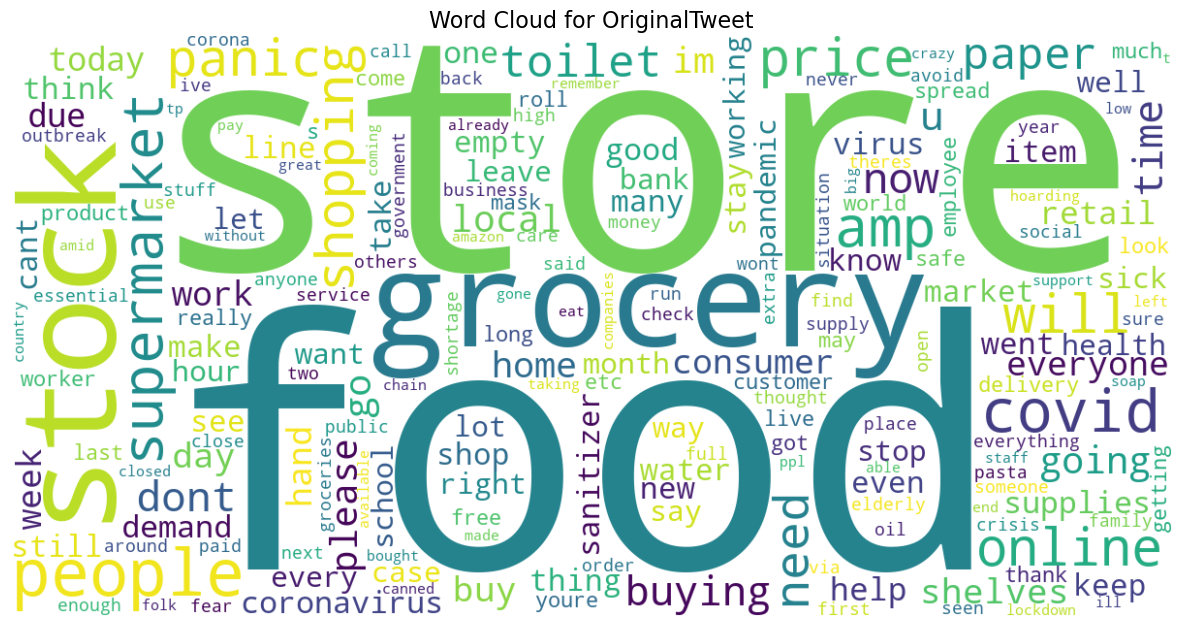

In [29]:
# Display
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for OriginalTweet", fontsize=16)
plt.show()

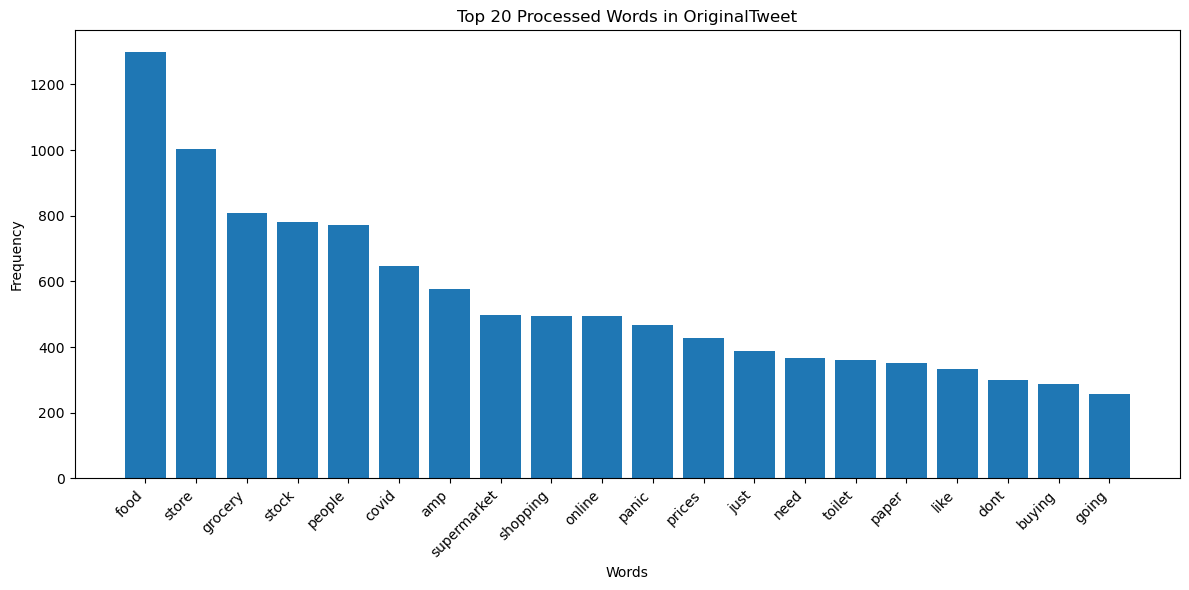

In [31]:
# Tokenize by splitting on spaces
tokens = text.split()

# Remove stopwords and very short words
processed_tokens = [
    word for word in tokens
    if word not in ENGLISH_STOP_WORDS and len(word) > 2
]

# Count top words
word_counts = Counter(processed_tokens)
top_words = word_counts.most_common(20)

# Separate words and counts
words = [word for word, count in top_words]
counts = [count for word, count in top_words]

# Bar chart
plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.title("Top 20 Processed Words in OriginalTweet")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()